## Gerrychain

In [2]:
import matplotlib.pyplot as plt
from gerrychain import Graph, Partition, proposals, updaters, constraints, accept, MarkovChain, Election
from gerrychain.updaters import cut_edges, Tally
from gerrychain.proposals import recom
from gerrychain.accept import always_accept
from functools import partial
import pandas as pd
import time

In [3]:
id_graph = Graph.from_file('./ID/ID.shp')


## 5K STEPS

  0%|          | 0/5000 [00:00<?, ?it/s]

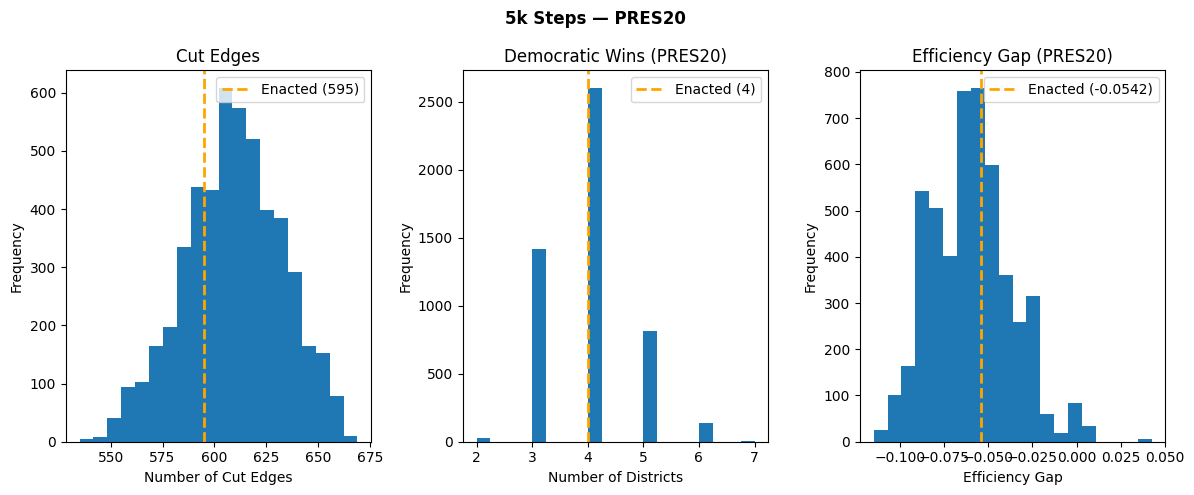

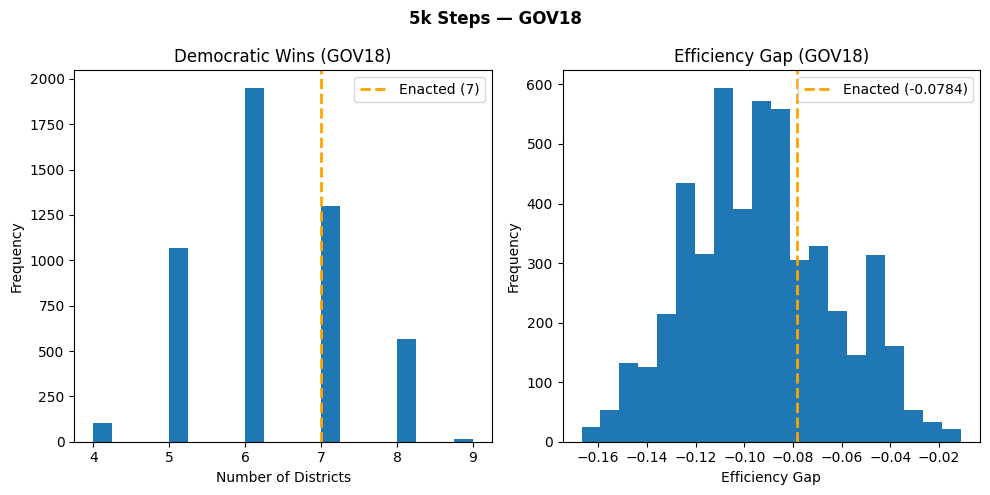

In [4]:
total_steps_in_run = 5000

elections = [
    Election('PRES20', {'Democratic': 'G20PREDBID', 'Republican': 'G20PRERTRU'}),
    Election('GOV18', {'Democratic': 'G18GOVDJOR', 'Republican': 'G18GOVRLIT'}),
]

my_updaters = {
    'population': updaters.Tally('TOTPOP', alias='population'),
    'cut_edges': cut_edges,
    'VAP': updaters.Tally('VAP', alias='VAP'),
}

election_updaters = {election.name: election for election in elections}
my_updaters.update(election_updaters)

initial_partition = Partition(
    id_graph,
    assignment='SDIST',
    updaters=my_updaters
)

ideal_population = sum(initial_partition['population'].values()) / len(initial_partition)

proposal = partial(recom,
                    pop_col='TOTPOP',
                    pop_target=ideal_population,
                    epsilon=0.5,
                    node_repeats=2
                )

compactness_bound = constraints.UpperBound(
    lambda p: len(p['cut_edges']),
    2 * len(initial_partition['cut_edges'])
)

pop_constraint = constraints.within_percent_of_ideal_population(initial_partition, 0.24)

chain = MarkovChain(
    proposal=proposal,
    constraints=[pop_constraint, compactness_bound],
    accept=always_accept,
    initial_state=initial_partition,
    total_steps=total_steps_in_run
)

cut_edges_data = []
dem_wins_data = []
eg_data = []
pres20_shares = []
gov18_shares = []
gov18_wins_data = []
gov18_eg_data = []

start_time = time.time()
for partition in chain.with_progress_bar():
    cut_edges_data.append(len(partition['cut_edges']))
    dem_wins_data.append(partition['PRES20'].wins('Democratic'))
    eg_data.append(partition['PRES20'].efficiency_gap())
    pres20_shares.append(partition['PRES20'].percents('Democratic'))
    gov18_shares.append(partition['GOV18'].percents('Democratic'))
    gov18_wins_data.append(partition['GOV18'].wins('Democratic'))
    gov18_eg_data.append(partition['GOV18'].efficiency_gap())

enacted_cut = cut_edges_data[0]
enacted_wins = dem_wins_data[0]
enacted_eg = eg_data[0]
enacted_gov18_wins = gov18_wins_data[0]
enacted_gov18_eg = gov18_eg_data[0]

# --- Row 1: PRES20 + Cut Edges ---
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
fig.suptitle('5k Steps — PRES20', fontweight='bold')

axes[0].hist(cut_edges_data, bins=20)
axes[0].axvline(enacted_cut, color='orange', linewidth=2, linestyle='--', label=f'Enacted ({enacted_cut})')
axes[0].set_title('Cut Edges')
axes[0].set_xlabel('Number of Cut Edges')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(dem_wins_data, bins=20)
axes[1].axvline(enacted_wins, color='orange', linewidth=2, linestyle='--', label=f'Enacted ({enacted_wins})')
axes[1].set_title('Democratic Wins (PRES20)')
axes[1].set_xlabel('Number of Districts')
axes[1].set_ylabel('Frequency')
axes[1].legend()

axes[2].hist(eg_data, bins=20)
axes[2].axvline(enacted_eg, color='orange', linewidth=2, linestyle='--', label=f'Enacted ({enacted_eg:.4f})')
axes[2].set_title('Efficiency Gap (PRES20)')
axes[2].set_xlabel('Efficiency Gap')
axes[2].set_ylabel('Frequency')
axes[2].legend()

plt.tight_layout()
plt.savefig('id_histograms_5k_pres20.png')
plt.show()

# --- Row 2: GOV18 ---
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('5k Steps — GOV18', fontweight='bold')

axes[0].hist(gov18_wins_data, bins=20)
axes[0].axvline(enacted_gov18_wins, color='orange', linewidth=2, linestyle='--', label=f'Enacted ({enacted_gov18_wins})')
axes[0].set_title('Democratic Wins (GOV18)')
axes[0].set_xlabel('Number of Districts')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(gov18_eg_data, bins=20)
axes[1].axvline(enacted_gov18_eg, color='orange', linewidth=2, linestyle='--', label=f'Enacted ({enacted_gov18_eg:.4f})')
axes[1].set_title('Efficiency Gap (GOV18)')
axes[1].set_xlabel('Efficiency Gap')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('id_histograms_5k_gov18.png')
plt.show()

In [5]:
import numpy as np

enacted_eg = eg_data[0]
enacted_wins = dem_wins_data[0]
enacted_cut = cut_edges_data[0]
enacted_gov18_wins = gov18_wins_data[0]
enacted_gov18_eg = gov18_eg_data[0]

eg_percentile = np.mean(np.array(eg_data) <= enacted_eg) * 100
wins_pct = np.mean(np.array(dem_wins_data) <= enacted_wins) * 100
cut_percentile = np.mean(np.array(cut_edges_data) <= enacted_cut) * 100
gov18_wins_pct = np.mean(np.array(gov18_wins_data) <= enacted_gov18_wins) * 100
gov18_eg_percentile = np.mean(np.array(gov18_eg_data) <= enacted_gov18_eg) * 100

print(f"Summary 5k steps:")
print(f"\n--- PRES20 ---")
print(f"Enacted EG:            {enacted_eg:.4f}")
print(f"Ensemble EG mean:      {np.mean(eg_data):.4f}  median: {np.median(eg_data):.4f}")
print(f"Enacted EG percentile: {eg_percentile:.1f}%")
print()
print(f"Enacted Dem wins:      {enacted_wins}")
print(f"Ensemble wins mean:    {np.mean(dem_wins_data):.2f}  median: {np.median(dem_wins_data):.1f}")
print(f"% plans <= enacted wins: {wins_pct:.1f}%")
print()
print(f"Enacted cut edges:     {enacted_cut}")
print(f"Ensemble cut mean:     {np.mean(cut_edges_data):.1f}  median: {np.median(cut_edges_data):.1f}")
print(f"Enacted cut percentile: {cut_percentile:.1f}%")

print(f"\n--- GOV18 ---")
print(f"Enacted EG:            {enacted_gov18_eg:.4f}")
print(f"Ensemble EG mean:      {np.mean(gov18_eg_data):.4f}  median: {np.median(gov18_eg_data):.4f}")
print(f"Enacted EG percentile: {gov18_eg_percentile:.1f}%")
print()
print(f"Enacted Dem wins:      {enacted_gov18_wins}")
print(f"Ensemble wins mean:    {np.mean(gov18_wins_data):.2f}  median: {np.median(gov18_wins_data):.1f}")
print(f"% plans <= enacted wins: {gov18_wins_pct:.1f}%")

Summary 5k steps:

--- PRES20 ---
Enacted EG:            -0.0542
Ensemble EG mean:      -0.0595  median: -0.0599
Enacted EG percentile: 62.4%

Enacted Dem wins:      4
Ensemble wins mean:    3.93  median: 4.0
% plans <= enacted wins: 80.9%

Enacted cut edges:     595
Ensemble cut mean:     609.2  median: 609.0
Enacted cut percentile: 27.7%

--- GOV18 ---
Enacted EG:            -0.0784
Ensemble EG mean:      -0.0928  median: -0.0925
Enacted EG percentile: 70.4%

Enacted Dem wins:      7
Ensemble wins mean:    6.24  median: 6.0
% plans <= enacted wins: 88.4%


## 20k STEPS

  0%|          | 0/10000 [00:00<?, ?it/s]

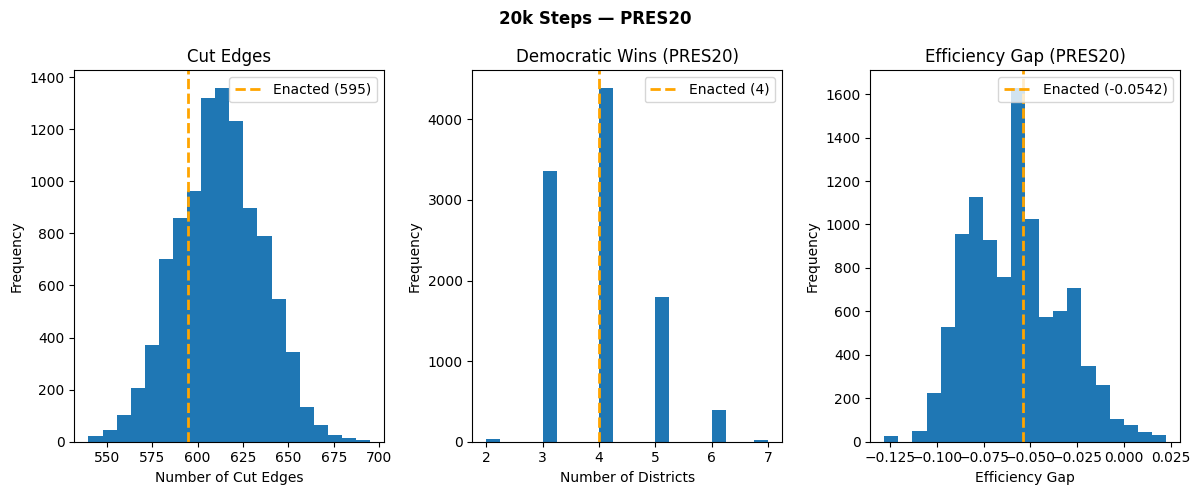

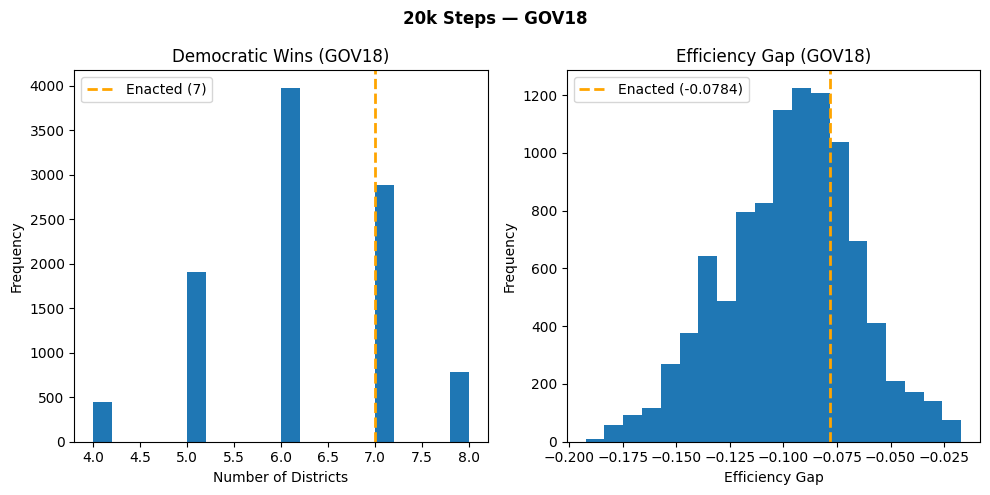

In [6]:
total_steps_in_run = 10000

elections = [
    Election('PRES20', {'Democratic': 'G20PREDBID', 'Republican': 'G20PRERTRU'}),
    Election('GOV18', {'Democratic': 'G18GOVDJOR', 'Republican': 'G18GOVRLIT'}),
]

my_updaters = {
    'population': updaters.Tally('TOTPOP', alias='population'),
    'cut_edges': cut_edges,
    'VAP': updaters.Tally('VAP', alias='VAP'),
}

election_updaters = {election.name: election for election in elections}
my_updaters.update(election_updaters)

initial_partition = Partition(
    id_graph,
    assignment='SDIST',
    updaters=my_updaters
)

ideal_population = sum(initial_partition['population'].values()) / len(initial_partition)

proposal = partial(recom,
                    pop_col='TOTPOP',
                    pop_target=ideal_population,
                    epsilon=0.5,
                    node_repeats=2
                )

compactness_bound = constraints.UpperBound(
    lambda p: len(p['cut_edges']),
    2 * len(initial_partition['cut_edges'])
)

pop_constraint = constraints.within_percent_of_ideal_population(initial_partition, 0.24)

chain = MarkovChain(
    proposal=proposal,
    constraints=[pop_constraint, compactness_bound],
    accept=always_accept,
    initial_state=initial_partition,
    total_steps=total_steps_in_run
)

cut_edges_data = []
dem_wins_data = []
eg_data = []
pres20_shares = []
gov18_shares = []
gov18_wins_data = []
gov18_eg_data = []

start_time = time.time()
for partition in chain.with_progress_bar():
    cut_edges_data.append(len(partition['cut_edges']))
    dem_wins_data.append(partition['PRES20'].wins('Democratic'))
    eg_data.append(partition['PRES20'].efficiency_gap())
    pres20_shares.append(partition['PRES20'].percents('Democratic'))
    gov18_shares.append(partition['GOV18'].percents('Democratic'))
    gov18_wins_data.append(partition['GOV18'].wins('Democratic'))
    gov18_eg_data.append(partition['GOV18'].efficiency_gap())

enacted_cut = cut_edges_data[0]
enacted_wins = dem_wins_data[0]
enacted_eg = eg_data[0]
enacted_gov18_wins = gov18_wins_data[0]
enacted_gov18_eg = gov18_eg_data[0]

# --- PRES20 + Cut Edges ---
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
fig.suptitle('20k Steps — PRES20', fontweight='bold')

axes[0].hist(cut_edges_data, bins=20)
axes[0].axvline(enacted_cut, color='orange', linewidth=2, linestyle='--', label=f'Enacted ({enacted_cut})')
axes[0].set_title('Cut Edges')
axes[0].set_xlabel('Number of Cut Edges')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(dem_wins_data, bins=20)
axes[1].axvline(enacted_wins, color='orange', linewidth=2, linestyle='--', label=f'Enacted ({enacted_wins})')
axes[1].set_title('Democratic Wins (PRES20)')
axes[1].set_xlabel('Number of Districts')
axes[1].set_ylabel('Frequency')
axes[1].legend()

axes[2].hist(eg_data, bins=20)
axes[2].axvline(enacted_eg, color='orange', linewidth=2, linestyle='--', label=f'Enacted ({enacted_eg:.4f})')
axes[2].set_title('Efficiency Gap (PRES20)')
axes[2].set_xlabel('Efficiency Gap')
axes[2].set_ylabel('Frequency')
axes[2].legend()

plt.tight_layout()
plt.savefig('id_histograms_20k_pres20.png')
plt.show()

# --- GOV18 ---
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('20k Steps — GOV18', fontweight='bold')

axes[0].hist(gov18_wins_data, bins=20)
axes[0].axvline(enacted_gov18_wins, color='orange', linewidth=2, linestyle='--', label=f'Enacted ({enacted_gov18_wins})')
axes[0].set_title('Democratic Wins (GOV18)')
axes[0].set_xlabel('Number of Districts')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(gov18_eg_data, bins=20)
axes[1].axvline(enacted_gov18_eg, color='orange', linewidth=2, linestyle='--', label=f'Enacted ({enacted_gov18_eg:.4f})')
axes[1].set_title('Efficiency Gap (GOV18)')
axes[1].set_xlabel('Efficiency Gap')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('id_histograms_20k_gov18.png')
plt.show()

In [7]:
enacted_eg = eg_data[0]
enacted_wins = dem_wins_data[0]
enacted_cut = cut_edges_data[0]
enacted_gov18_wins = gov18_wins_data[0]
enacted_gov18_eg = gov18_eg_data[0]

eg_percentile = np.mean(np.array(eg_data) <= enacted_eg) * 100
wins_pct = np.mean(np.array(dem_wins_data) <= enacted_wins) * 100
cut_percentile = np.mean(np.array(cut_edges_data) <= enacted_cut) * 100
gov18_wins_pct = np.mean(np.array(gov18_wins_data) <= enacted_gov18_wins) * 100
gov18_eg_percentile = np.mean(np.array(gov18_eg_data) <= enacted_gov18_eg) * 100

print(f"Summary 20k steps:")
print(f"\n--- PRES20 ---")
print(f"Enacted EG:            {enacted_eg:.4f}")
print(f"Ensemble EG mean:      {np.mean(eg_data):.4f}  median: {np.median(eg_data):.4f}")
print(f"Enacted EG percentile: {eg_percentile:.1f}%")
print()
print(f"Enacted Dem wins:      {enacted_wins}")
print(f"Ensemble wins mean:    {np.mean(dem_wins_data):.2f}  median: {np.median(dem_wins_data):.1f}")
print(f"% plans <= enacted wins: {wins_pct:.1f}%")
print()
print(f"Enacted cut edges:     {enacted_cut}")
print(f"Ensemble cut mean:     {np.mean(cut_edges_data):.1f}  median: {np.median(cut_edges_data):.1f}")
print(f"Enacted cut percentile: {cut_percentile:.1f}%")

print(f"\n--- GOV18 ---")
print(f"Enacted EG:            {enacted_gov18_eg:.4f}")
print(f"Ensemble EG mean:      {np.mean(gov18_eg_data):.4f}  median: {np.median(gov18_eg_data):.4f}")
print(f"Enacted EG percentile: {gov18_eg_percentile:.1f}%")
print()
print(f"Enacted Dem wins:      {enacted_gov18_wins}")
print(f"Ensemble wins mean:    {np.mean(gov18_wins_data):.2f}  median: {np.median(gov18_wins_data):.1f}")
print(f"% plans <= enacted wins: {gov18_wins_pct:.1f}%")

Summary 20k steps:

--- PRES20 ---
Enacted EG:            -0.0542
Ensemble EG mean:      -0.0583  median: -0.0581
Enacted EG percentile: 59.3%

Enacted Dem wins:      4
Ensemble wins mean:    3.92  median: 4.0
% plans <= enacted wins: 77.8%

Enacted cut edges:     595
Ensemble cut mean:     611.9  median: 612.0
Enacted cut percentile: 24.4%

--- GOV18 ---
Enacted EG:            -0.0784
Ensemble EG mean:      -0.0969  median: -0.0945
Enacted EG percentile: 72.6%

Enacted Dem wins:      7
Ensemble wins mean:    6.17  median: 6.0
% plans <= enacted wins: 92.1%


/Users/sid/opt/anaconda3/envs/gerry2/lib/python3.11/site-packages/pandas/plotting/_matplotlib/boxplot.py:112: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(ys, **kwds)
/Users/sid/opt/anaconda3/envs/gerry2/lib/python3.11/site-packages/pandas/plotting/_matplotlib/boxplot.py:112: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(ys, **kwds)


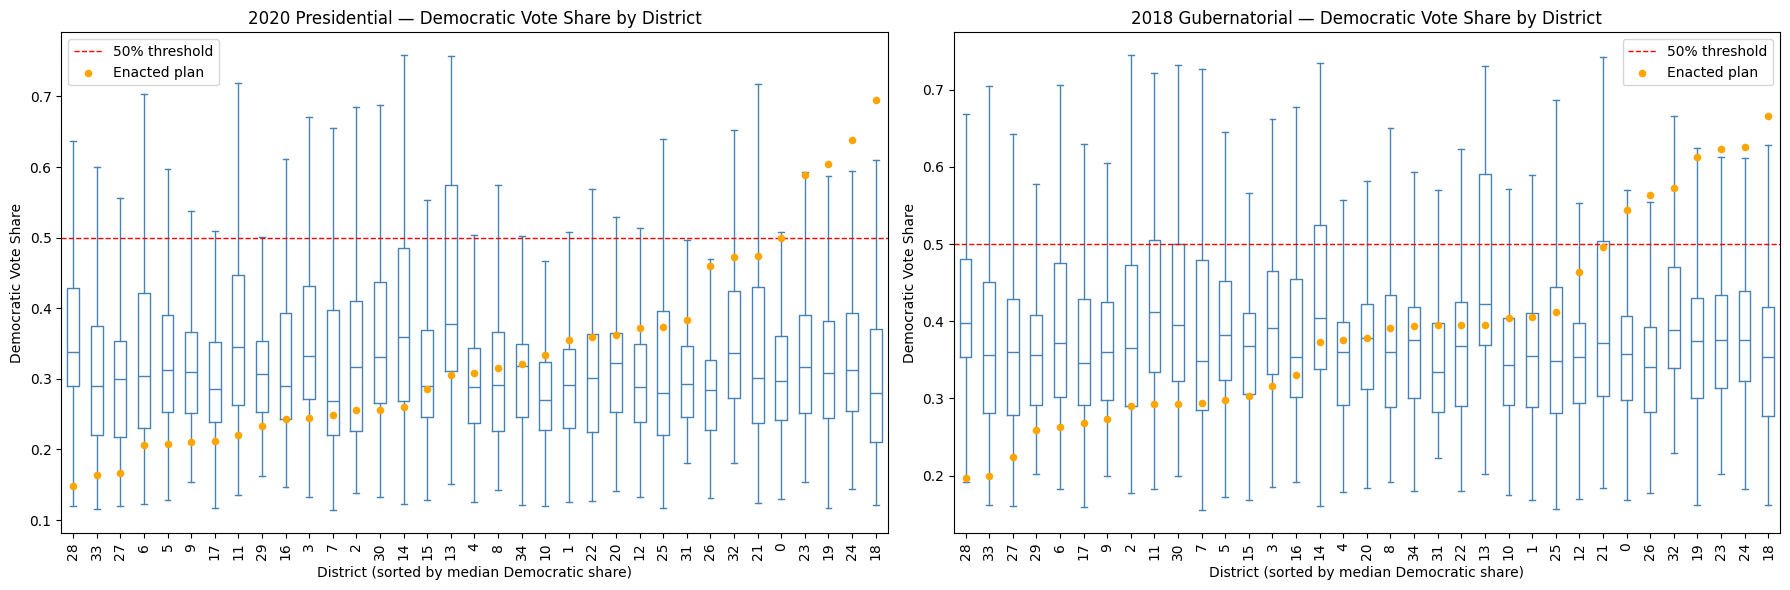

In [14]:
pres20_df = pd.DataFrame(pres20_shares)
gov18_df = pd.DataFrame(gov18_shares)


pres20_enacted = pres20_shares[0]
gov18_enacted = gov18_shares[0]

enacted_order = sorted(range(len(pres20_enacted)), key=lambda i: pres20_enacted[i])                                                
pres20_sorted = pres20_df.iloc[:, enacted_order]
gov18_sorted = gov18_df[sorted(gov18_df.columns, key=lambda d: gov18_enacted[d])]    

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, df, enacted, title in [
    (axes[0], pres20_sorted, pres20_enacted, '2020 Presidential — Democratic Vote Share by District'),
    (axes[1], gov18_sorted, gov18_enacted, '2018 Gubernatorial — Democratic Vote Share by District'),
]:
    df.plot.box(ax=ax, vert=True, showfliers=False, color='steelblue')
    ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='50% threshold')
    enacted_vals = [enacted[d] for d in df.columns]
    ax.scatter(range(1, len(df.columns) + 1), enacted_vals,
               color='orange', zorder=5, s=20, label='Enacted plan')
    ax.set_title(title)
    ax.set_xlabel('District (sorted by median Democratic share)')
    ax.set_ylabel('Democratic Vote Share')
    ax.tick_params(axis='x', rotation=90)
    ax.legend()

plt.tight_layout()
plt.savefig('id_boxplots.png', dpi=150)
plt.show()

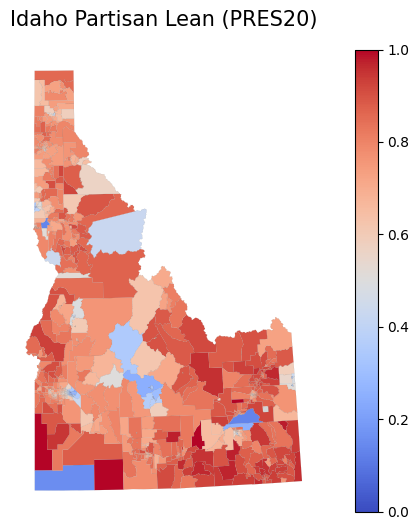

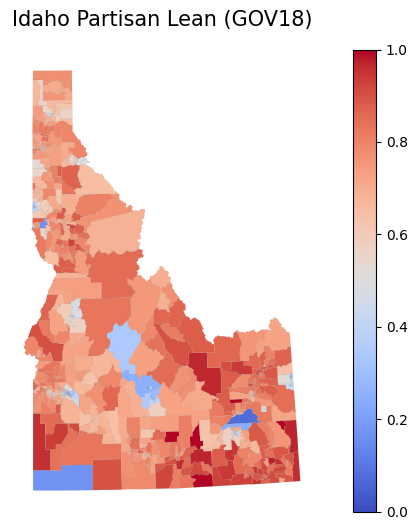

In [9]:
#Professor Ellen's Choropleth code
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Thu Feb  8 10:13:02 2024

@author: eveomett
"""

import random
import pandas as pd

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np

df = gpd.read_file('./ID/ID.shp')

for (dem_col, rep_col, title, outfile) in [
    ('G20PREDBID', 'G20PRERTRU', 'Idaho Partisan Lean (PRES20)', 'ID_pres20.png'),
    ('G18GOVDJOR', 'G18GOVRLIT', 'Idaho Partisan Lean (GOV18)', 'ID_gov18.png'),
]:
    df["Partisan Lean"] = df[rep_col] / (df[rep_col] + df[dem_col])

    fig, ax = plt.subplots(1, figsize=(10, 6))
    ax.axis('off')
    ax.set_title(title, fontdict={'fontsize': '15', 'fontweight': '3'})
    df.plot(column='Partisan Lean',
            cmap='coolwarm',
            linewidth=0.05,
            ax=ax,
            edgecolor='0.4',
            vmin=0,
            vmax=1,
            legend=True,
            missing_kwds={"color": "lightgrey", "label": "Missing values"})
    plt.savefig(outfile)
    plt.show()

In [10]:
end_time = time.time()
print('The time of execution of above program is :',
      (end_time-start_time)/60, 'mins')

The time of execution of above program is : 2.689574134349823 mins
